# AFCON 2023 Final: Data Analysis
### Nigeria 🇳🇬 vs Ivory Coast 🇨🇮 | February 11, 2024
### Notebook Series — Part A: Individual Player Pass Map

### Task

Using `StatsBomb` open event data, load the AFCON 2023 Final between Nigeria and Ivory Coast, select a player from the Ivory Coast squad, and visualize all passes made by that player during the match on a football pitch using `mplsoccer`.

---

> **Data Source:** [StatsBomb Open Data](https://github.com/statsbomb/open-data)  
> **competition_id:** 1267  
> **season_id:** 107  
> **match_id:** 3923881  
> **Player Analysed:** Jean Michaël Seri

---

## 1. Environment Setup

### 1.1 Import Libraries

We import `pandas` and `numpy` for data manipulation and numerical operations, `matplotlib.pyplot` for figure rendering, `matplotlib.patheffects` for text styling effects, `matplotlib.patches` for legend elements, and `mplsoccer` — specifically `Pitch` and `Sbopen` for pitch drawing and StatsBomb data access.

In [1]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from mplsoccer import Pitch, Sbopen

### 1.2 Load Competitions and Matches Using `Sbopen`

We use `Sbopen` to load all available StatsBomb competitions and matches, then select the **AFCON 2023 Final** (Nigeria VS Ivory Coast) using `match_id = 3923881`.

In [2]:
# Initialise the StatsBomb parser
parser = Sbopen()

# List all available competitions
df_comp = parser.competition()
df_comp.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,None,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


### 1.3 Load Match Events

Load all matches for the AFCON 2023 competition, confirm the target fixture, then load the full event stream for `match_id = 3923881`.

In [3]:
# Define identifiers for the target match
competition_id = 1267
season_id      = 107
match_id       = 3923881

# Load all matches for this competition and season
df_match = parser.match(competition_id, season_id)

# Confirm the AFCON 2023 Final is present
df_match[df_match['match_id'] == match_id][
    ['competition_id', 'season_id', 'match_id', 'home_team_name', 'away_team_name']
]

,competition_id,season_id,match_id,home_team_name,away_team_name
24,1267,107,3923881,Nigeria,Côte d'Ivoire


In [4]:
# Load all events for the selected match
# parser.event() returns four DataFrames:
#   df       – main event data
#   related  – related event links
#   freeze   – freeze-frame data (shots)
#   tactics  – lineup/tactical data
df, related, freeze, tactics = parser.event(match_id)
df.head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,block_offensive,foul_committed_offensive,bad_behaviour_card_id,bad_behaviour_card_name,substitution_replacement_id,substitution_replacement_name,pass_goal_assist,pass_cut_back,foul_committed_card_id,foul_committed_card_name
0,43446b4c-472f-4c9b-a6c8-c40fd9d38328,1,1,00:00:00,0,0,1,0.000000,3923881,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5195a0f0-95db-4cb4-bbaa-b9dd05f2114e,2,1,00:00:00,0,0,1,0.000000,3923881,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,06b5ec1f-cab0-4bbc-ab5e-d88e5b2ffdbc,3,1,00:00:00,0,0,1,0.000000,3923881,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8252893b-c231-487c-83ad-b4a167b63bc8,4,1,00:00:00,0,0,1,0.000000,3923881,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8b8272c8-f07f-4514-96a7-413cc3c7f4f5,5,1,00:00:00.663000,0,0,2,1.773278,3923881,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 Filter Pass Events

From the full event data, keep only rows where `type_name == 'Pass'`, then filter further to retain only passes made by **Jean Michaël Seri**.

In [5]:
# Isolate pass events
passes = df[df['type_name'] == 'Pass'].copy()

# Review the top passers in the match (sanity check)
passes['player_name'].value_counts().head(20)

player_name
Ghislain Konan                         77
Jean Michaël Seri                      66
Obite Evan Ndicka                      55
Odilon Kossonou                        55
Simon Adingra                          40
Calvin Bassey Ughelumba                38
Serge Aurier                           37
Franck Yannick Kessié                  33
William Troost-Ekong                   29
Temitayo Olufisayo Olaoluwa Aina       29
Seko Fofana                            29
Zaidu Sanusi                           28
Stanley Bobo Nwabali                   27
Oluwasemilogo Adesewo Ibidapo Ajayi    25
Max-Alain Gradel                       23
Alex Iwobi                             21
Yahia Fofana                           17
Ademola Lookman                        14
Moses Daddy-Ajala Simon                14
Sébastien Haller                       12
Name: count, dtype: int64

In [6]:
# Filter to the target player
PLAYER_NAME  = 'Jean Michaël Seri'  
player_passes = passes[passes['player_name'] == PLAYER_NAME].copy()

### 1.5 Filter Passes by Outcome

In StatsBomb data, **completed passes have no `outcome_name`** (the field is `NaN`), while incomplete passes carry an explicit outcome label (e.g. *Incomplete*, *Out*, *Pass Offside*). We split accordingly and compute pass accuracy.

In [7]:
# Completed passes: outcome_name is NaN
completed   = player_passes[player_passes['outcome_name'].isna()].copy()

# Incomplete passes: outcome_name has a value
incomplete  = player_passes[player_passes['outcome_name'].notna()].copy()

# Guard against division by zero
total_passes  = len(player_passes)
pass_accuracy = (len(completed) / total_passes * 100) if total_passes > 0 else 0.0

print(f'Player         : {PLAYER_NAME}')
print(f'Total Passes   : {total_passes}')
print(f'Completed      : {len(completed)}')
print(f'Incomplete     : {len(incomplete)}')
print(f'Pass Accuracy  : {pass_accuracy:.1f}%')

Player         : Jean Michaël Seri
Total Passes   : 66
Completed      : 61
Incomplete     : 5
Pass Accuracy  : 92.4%


## 2. Visualize the Pass Map

Plot all passes on a **StatsBomb pitch** using `Pitch` from `mplsoccer` with:
- A dark green background (`pitch_color="#22312b"`)
- **Green arrows** for completed passes
- **Red arrows** for incomplete passes
- A legend and a subtle watermark

### 2.1 Create the Pitch

> **Note:** All drawing steps (pitch, arrows, title, legend, watermark) are combined into a single code cell below. This ensures `fig` and `ax` remain in scope throughout and the final `plt.savefig` captures every layer.

### 2.2 Plot Completed Passes

### 2.3 Plot Incomplete Passes

### 2.4 Finalize and Display the Pass Map

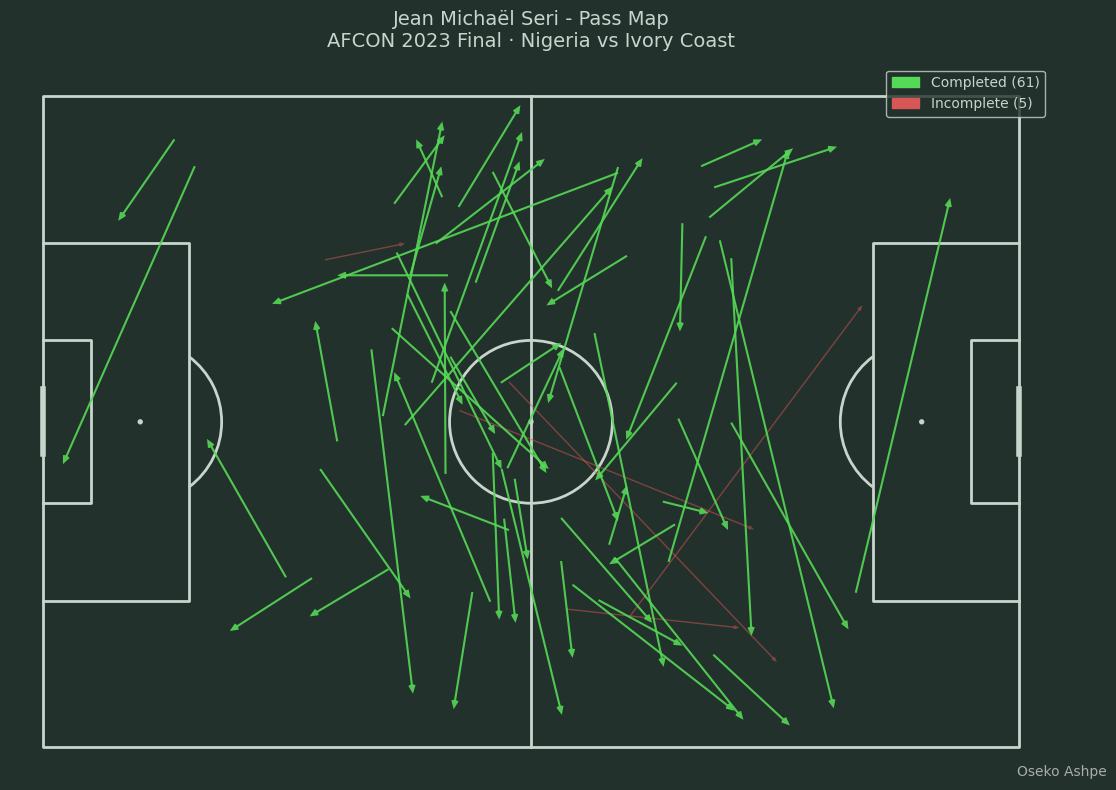

In [8]:
# 2.1 Create the pitch
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#22312b',
    line_color='#c7d5cc'
)

fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#22312b')

# 2.2 Completed passes (green arrows) 
pitch.arrows(
    completed['x'],     completed['y'],
    completed['end_x'], completed['end_y'],
    ax=ax,
    color='#56d956',
    width=1.5,
    headwidth=3.5,
    headlength=4,
    alpha=0.9,
    zorder=3
)

# 2.3 Incomplete passes (red arrows)
pitch.arrows(
    incomplete['x'],     incomplete['y'],
    incomplete['end_x'], incomplete['end_y'],
    ax=ax,
    color='#d95656',
    width=1.0,
    headwidth=3,
    headlength=3.5,
    alpha=0.5,
    zorder=2
)

# 2.4 Title, legend, watermark, save 
ax.set_title(
    f'{PLAYER_NAME} - Pass Map\nAFCON 2023 Final · Nigeria vs Ivory Coast',
    fontsize=14, color='#c7d5cc', pad=12
)

completed_patch  = mpatches.Patch(color='#56d956', label=f'Completed ({len(completed)})')
incomplete_patch = mpatches.Patch(color='#d95656', label=f'Incomplete ({len(incomplete)})')

ax.legend(
    handles=[completed_patch, incomplete_patch],
    facecolor='#22312b', edgecolor='#c7d5cc',
    labelcolor='#c7d5cc', fontsize=10
)

# Subtle watermark
fig.text(0.98, 0.02, "Oseko Ashpe",
         fontsize=10,
         color="white",
         alpha=0.6,
         ha="right",
         va="bottom")

plt.tight_layout()
plt.savefig('pass_map.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Interpretation of the Pass Map

The pass map above shows all passes attempted by **Jean Michaël Seri** for Ivory Coast in the AFCON 2023 Final against Nigeria (`competition_id = 1267`, `season_id = 107`, `match_id = 3923881`).  
Successful passes are represented by green arrows and unsuccessful ones by red arrows, plotted on a dark-green StatsBomb pitch.

### 3.1 Overall Involvement and Positioning

Jean Michaël Seri attempted **66 passes**, completing **61** and missing only **5**, for a pass completion rate of approximately **92%**. This high volume and accuracy indicate that he was heavily involved in Ivory Coast's build-up play and served as a key outlet in possession. Most of his passes originated from central midfield areas, particularly around and just ahead of the centre circle, suggesting he operated as a deep-lying or central midfielder responsible for linking defence and attack.

### 3.2 Passing Distribution and Risk Profile

The pass map reveals passes played in multiple directions: forward, sideways, and backward. This multi-directional pattern is typical of a midfielder tasked with controlling possession and dictating tempo. Seri also demonstrated a wide passing range, with several long diagonal passes to the flanks and numerous medium-range vertical passes that helped switch play and stretch Nigeria's defensive shape. Despite attempting ambitious forward and diagonal passes, he registered only five incomplete passes, indicating a controlled yet progressive passing style.

### 3.3 Overall Match Contribution

The pass map suggests that Seri functioned as a deep-lying playmaker rather than a purely defensive midfielder. He consistently made himself available for teammates, connected different areas of the pitch, switched play effectively, and advanced attacks through his distribution. Based on this pass map, Seri was one of Ivory Coast's primary possession hubs in the AFCON 2023 Final, combining high volume with excellent accuracy and a willingness to play progressive passes.